# 02 — TWFE DiD and Event Study

Baseline two-way fixed effects regression of unemployment on log(minimum wage), plus an event-study specification to check the parallel-trends assumption.

In [1]:
import sys
from pathlib import Path

# Walk up to the project root so the notebook runs from any working directory.
root = next(p for p in Path.cwd().resolve().parents if (p / "src").is_dir())
sys.path.insert(0, str(root))


In [2]:
from src.data.loader import load_state_year_panel
from src.methods.twfe_did import estimate_twfe, summarize_twfe

panel, is_synthetic = load_state_year_panel()
result = estimate_twfe(panel)
print(result.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:      unemployment_rate   R-squared:                        0.0034
Estimator:                   PanelOLS   R-squared (Between):              0.3598
No. Observations:                1173   R-squared (Within):               0.0038
Date:                Sun, Jul 26 2026   R-squared (Overall):              0.3277
Time:                        09:08:40   Log-likelihood                   -1400.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      3.7357
Entities:                          51   P-value                           0.0535
Avg Obs:                       23.000   Distribution:                  F(1,1099)
Min Obs:                       23.000                                           
Max Obs:                       23.000   F-statistic (robust):             0.8910
                            

In [3]:
summarize_twfe(result)

,coef,std_error,pvalue,ci_lower,ci_upper
log_minimum_wage,0.575461,0.609635,0.345406,-0.62072,1.771641


## Event study

In [ ]:
from src.methods.event_study import average_post_effect, estimate_event_study

# Never-treated states stay in the sample as the control group; always-treated
# states (no pre-period) are dropped. Without that, the leads and lags would be
# identified only by differential timing among treated states.
es_result, es_summary = estimate_event_study(panel)
print(f"{es_summary.attrs['n_adopters']} adopters, "
      f"{es_summary.attrs['n_never_treated']} never-treated controls, "
      f"{len(es_summary.attrs['always_treated_states'])} always-treated dropped")
es_summary

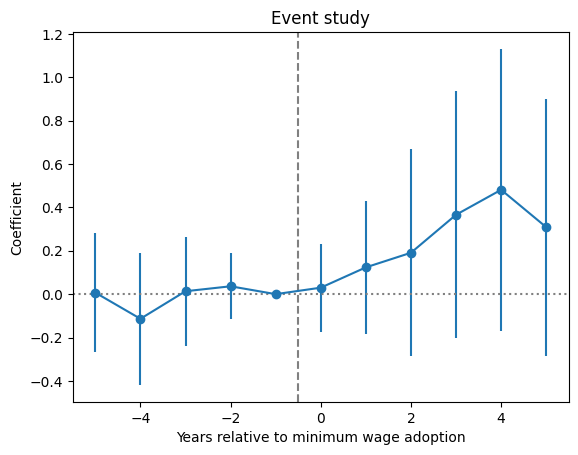

In [5]:
import matplotlib.pyplot as plt

plt.errorbar(es_summary.rel_time, es_summary.coef,
             yerr=[es_summary.coef - es_summary.ci_lower, es_summary.ci_upper - es_summary.coef],
             fmt='o-')
plt.axvline(-0.5, color='gray', linestyle='--')
plt.axhline(0, color='gray', linestyle=':')
plt.xlabel('Years relative to minimum wage adoption'); plt.ylabel('Coefficient')
plt.title('Event study'); plt.show()

## Pre-trend check

In [ ]:
from src.diagnostics.parallel_trends import pretrend_joint_test

# A genuine joint Wald test over the lead coefficients, using the fitted
# state-clustered covariance matrix. Checking each lead's own CI one at a time
# is a screening pass, not a test -- it is carried along under
# 'individual_screen' to show which lead moves if the joint test rejects.
joint = pretrend_joint_test(es_result, es_summary)
print(f"leads tested:        {joint['leads_tested']}")
print(f"chi2({joint['df']}) = {joint['statistic']:.2f}, p = {joint['p_value']:.3f}")
print(f"no detectable pre-trend: {joint['passes']}")
print(f"individual screen:   {joint['individual_screen']}")

post = average_post_effect(es_result, es_summary)
print(f"
post-period average: {post['estimate']:+.3f} "
      f"[{post['ci_lower']:+.3f}, {post['ci_upper']:+.3f}] (se {post['std_error']:.3f})")